## (0) Settings and Functions

In [1]:
%load_ext autotime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    KFold, RepeatedKFold, cross_validate, learning_curve, train_test_split
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    make_scorer, accuracy_score, f1_score, precision_score,
    recall_score, hamming_loss
)

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler

from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import itertools

from imblearn.over_sampling import SMOTE
from collections import Counter

import warnings
from sklearn.exceptions import UndefinedMetricWarning

from scipy.sparse import hstack

warnings.filterwarnings(
    "ignore",
    category=UndefinedMetricWarning
)

time: 10.2 s (started: 2026-02-24 05:30:42 -03:00)


In [2]:
df = pd.read_csv("../../data/feat/go_emotions_with_features.csv")

print(df.shape)
df.head(3)

(54234, 56)


,UNCLEAN_TEXT_PT,BASE_TEXT_PT,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,punctuation_per_word,exclamation_per_word,question_per_word,mean_verbs_per_word,mean_auxiliaries_per_word,mean_auxiliaries_per_sentence,flesch_portuguese,uppercase_percentage,mean_unique_word_length,mean_char_repetition_per_word
0,Tão rápido quanto [NOME] me carregará. Seriame...,tao rapido quanto nome carregara seriamente up...,0,0,0,0,1,0,0,0,...,0.142857,0.0,0.0,0.095238,0.047619,0.5,77.937143,0.073684,4.388889,0.0
1,Você estragou isso. Eles tocaram você como um ...,voce estragou isso eles tocaram voce como violino,0,0,0,0,0,0,0,0,...,0.222222,0.0,0.0,0.222222,0.000000,0.0,61.320000,0.045455,4.833333,0.0
2,TL;DR Não há mais Super Bowls para [NAME]. Pre...,nao mais super bowls para name prepare-se para...,0,0,0,0,0,0,0,0,...,0.333333,0.0,0.0,0.125000,0.062500,0.5,72.640000,0.134831,4.666667,0.0


time: 849 ms (started: 2026-02-24 05:30:52 -03:00)


In [3]:
def evaluate_cv_smote_per_label(base_model, X, y, emotion_cols, numerical_features, n_splits=5, n_repeats=6, random_state=42):
    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)

    metrics = {
        "accuracy": [],
        "precision_macro": [],
        "recall_macro": [],
        "f1_macro": [],
        "f1_weighted": [],
        "f1_micro": [],
    }

    per_label_metrics = {label: [] for label in emotion_cols}

    for fold_idx, (train_idx, test_idx) in enumerate(rkf.split(X)):
        print(f"→ Fold {fold_idx + 1}")

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        vectorizer = CountVectorizer()
        X_train_text = vectorizer.fit_transform(X_train["BASE_TEXT_PT"])
        X_test_text = vectorizer.transform(X_test["BASE_TEXT_PT"])

        scaler = StandardScaler()
        X_train_num = scaler.fit_transform(
            X_train[numerical_features]
        )
        X_test_num = scaler.transform(
            X_test[numerical_features]
        )

        X_train_full = hstack([X_train_text, X_train_num])
        X_test_full = hstack([X_test_text, X_test_num])

        y_pred_fold = np.zeros_like(y_test)


        for label_idx, label_name in enumerate(emotion_cols):

            y_train_label = y_train[:, label_idx]

            if len(np.unique(y_train_label)) > 1:
                smote = SMOTE(random_state=random_state)
                X_res, y_res = smote.fit_resample(
                    X_train_full, y_train_label
                )
            else:
                X_res, y_res = X_train_full, y_train_label

            clf = clone(base_model)
            clf.fit(X_res, y_res)

            y_pred_label = clf.predict(X_test_full)

            y_pred_fold[:, label_idx] = y_pred_label

            per_label_metrics[label_name].append(
                f1_score(
                    y_test[:, label_idx],
                    y_pred_label,
                    zero_division=0
                )
            )

        metrics["accuracy"].append(
            accuracy_score(y_test, y_pred_fold)
        )

        metrics["precision_macro"].append(
            precision_score(
                y_test,
                y_pred_fold,
                average="macro",
                zero_division=0
            )
        )

        metrics["recall_macro"].append(
            recall_score(
                y_test,
                y_pred_fold,
                average="macro",
                zero_division=0
            )
        )

        metrics["f1_macro"].append(
            f1_score(
                y_test,
                y_pred_fold,
                average="macro",
                zero_division=0
            )
        )

        metrics["f1_weighted"].append(
            f1_score(
                y_test,
                y_pred_fold,
                average="weighted",
                zero_division=0
            )
        )

        metrics["f1_micro"].append(
            f1_score(
                y_test,
                y_pred_fold,
                average="micro",
                zero_division=0
            )
        )

    results = {
        "Accuracy": (
            np.mean(metrics["accuracy"]),
            np.std(metrics["accuracy"]),
            np.array(metrics["accuracy"])
        ),
        "Precision_macro": (
            np.mean(metrics["precision_macro"]),
            np.std(metrics["precision_macro"]),
            np.array(metrics["precision_macro"])
        ),
        "Recall_macro": (
            np.mean(metrics["recall_macro"]),
            np.std(metrics["recall_macro"]),
            np.array(metrics["recall_macro"])
        ),
        "F1_macro": (
            np.mean(metrics["f1_macro"]),
            np.std(metrics["f1_macro"]),
            np.array(metrics["f1_macro"])
        ),
        "F1_weighted": (
            np.mean(metrics["f1_weighted"]),
            np.std(metrics["f1_weighted"]),
            np.array(metrics["f1_weighted"])
        ),
        "F1_micro": (
            np.mean(metrics["f1_micro"]),
            np.std(metrics["f1_micro"]),
            np.array(metrics["f1_micro"])
        ),
    }

    per_label_df = pd.DataFrame({
        label: (
            np.mean(scores),
            np.std(scores)
        )
        for label, scores in per_label_metrics.items()
    }).T

    per_label_df.columns = ["F1_mean", "F1_std"]

    return results, per_label_df

time: 2.59 ms (started: 2026-02-24 05:30:53 -03:00)


In [4]:
df['BASE_TEXT_PT'] = (
    df['BASE_TEXT_PT']
    .fillna("")
    .astype(str)
)

emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

numerical_features = [
    'letter_count', 'sentence_count', 'avg_letter_per_word', 'words_per_sentence', 'avg_syllables_per_word', 
    'reading_time', 'punctuation_per_word', 'exclamation_per_word', 'question_per_word', 'mean_verbs_per_word',
    'mean_auxiliaries_per_word', 'mean_auxiliaries_per_sentence', 'flesch_portuguese', 
    'uppercase_percentage', 'mean_unique_word_length', 'mean_char_repetition_per_word'
]

cols_input = ['BASE_TEXT_PT'] + numerical_features

X = df[cols_input]
y = df[emotion_cols].values

X_train, X_aux, y_train, y_aux = train_test_split(
    X, y,
    train_size=0.70,
    random_state=42,
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_aux, y_aux,
    train_size=0.50,
    random_state=42,
)

print(X_train.shape, X_dev.shape, X_test.shape)

(37963, 17) (8135, 17) (8136, 17)
time: 40 ms (started: 2026-02-24 05:30:53 -03:00)


In [5]:
models_for_testing = {
    "LogisticRegression": OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)),
    "RidgeClassifier": RidgeClassifier(random_state=42),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42)),
    # "RandomForest": RandomForestClassifier(random_state=42),
    "XGBClassifier": OneVsRestClassifier(
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            verbosity=0
    ))
}

results = []

def run_predictions(name, model, X_train, y_train):
    print("\n" + "=" * 80)
    print(f"Running model: {name}")
    print("=" * 80)

    cv_res, per_label_df = evaluate_cv_smote_per_label(
        base_model=model,
        X=X_train,
        y=y_train,
        emotion_cols=emotion_cols,
        numerical_features=numerical_features,
        n_splits=5,
        n_repeats=6
    )

    results.append({
        "Model": name,

        "CV_Accuracy_mean":  cv_res["Accuracy"][0],
        "CV_Accuracy_std":   cv_res["Accuracy"][1],
        "CV_Accuracy_all":   cv_res["Accuracy"][2],

        "CV_Precision_macro_mean":  cv_res["Precision_macro"][0],
        "CV_Precision_macro_std":   cv_res["Precision_macro"][1],
        "CV_Precision_macro_all":   cv_res["Precision_macro"][2],

        "CV_Recall_macro_mean":  cv_res["Recall_macro"][0],
        "CV_Recall_macro_std":   cv_res["Recall_macro"][1],
        "CV_Recall_macro_all":   cv_res["Recall_macro"][2],

        "CV_F1_macro_mean":  cv_res["F1_macro"][0],
        "CV_F1_macro_std":   cv_res["F1_macro"][1],
        "CV_F1_macro_all":   cv_res["F1_macro"][2],

        "CV_F1_weighted_mean":  cv_res["F1_weighted"][0],
        "CV_F1_weighted_std":   cv_res["F1_weighted"][1],
        "CV_F1_weighted_all":   cv_res["F1_weighted"][2],

        "CV_F1_micro_mean":  cv_res["F1_micro"][0],
        "CV_F1_micro_std":   cv_res["F1_micro"][1],
        "CV_F1_micro_all":   cv_res["F1_micro"][2]
    })

for name, model in models_for_testing.items():
    run_predictions(name, model, X_train, y_train)


Running model: LogisticRegression
→ Fold 1
→ Fold 2
→ Fold 3
→ Fold 4
→ Fold 5
→ Fold 6
→ Fold 7
→ Fold 8
→ Fold 9
→ Fold 10
→ Fold 11
→ Fold 12
→ Fold 13
→ Fold 14
→ Fold 15
→ Fold 16
→ Fold 17
→ Fold 18
→ Fold 19
→ Fold 20
→ Fold 21
→ Fold 22
→ Fold 23
→ Fold 24
→ Fold 25
→ Fold 26
→ Fold 27
→ Fold 28
→ Fold 29
→ Fold 30

Running model: RidgeClassifier
→ Fold 1
→ Fold 2
→ Fold 3
→ Fold 4
→ Fold 5
→ Fold 6
→ Fold 7
→ Fold 8
→ Fold 9
→ Fold 10
→ Fold 11
→ Fold 12
→ Fold 13
→ Fold 14
→ Fold 15
→ Fold 16
→ Fold 17
→ Fold 18
→ Fold 19
→ Fold 20
→ Fold 21
→ Fold 22
→ Fold 23
→ Fold 24
→ Fold 25
→ Fold 26
→ Fold 27
→ Fold 28
→ Fold 29
→ Fold 30

Running model: LinearSVC
→ Fold 1


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-d

→ Fold 2


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-d

→ Fold 3


...

→ Fold 29


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-d

→ Fold 30


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Running model: XGBClassifier
→ Fold 1
→ Fold 2
→ Fold 3
→ Fold 4
→ Fold 5
→ Fold 6
→ Fold 7
→ Fold 8
→ Fold 9
→ Fold 10
→ Fold 11
→ Fold 12
→ Fold 13
→ Fold 14
→ Fold 15
→ Fold 16
→ Fold 17
→ Fold 18
→ Fold 19
→ Fold 20
→ Fold 21
→ Fold 22
→ Fold 23
→ Fold 24
→ Fold 25
→ Fold 26
→ Fold 27
→ Fold 28
→ Fold 29
→ Fold 30
time: 3h 46min 28s (started: 2026-02-24 05:30:53 -03:00)


In [6]:
df_results = pd.DataFrame(results)
best_model = df_results.sort_values(by="CV_F1_macro_mean", ascending=False).iloc[0]["Model"]
print("Best model:", best_model)

Best model: LogisticRegression
time: 6.88 ms (started: 2026-02-24 09:17:22 -03:00)


In [7]:
def format_results(df):
    formatted_df = df.copy()

    for metric in ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro"]:
        mean_col = f"CV_{metric}_mean"
        std_col = f"CV_{metric}_std"

        formatted_df[metric] = (
            formatted_df[mean_col].round(4).astype(str)
            + " ± "
            + formatted_df[std_col].round(4).astype(str)
        )

        # Remove as colunas originais
        formatted_df = formatted_df.drop(columns=[mean_col, std_col])

    # reorganiza colunas
    cols = ["Model", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro"]
    return formatted_df[cols]

df_results.to_csv("../../data/out/feat/feat_05_GoEmotions_BoW_SMOTE.csv")
formatted_df = format_results(df_results)
formatted_df.style.hide(axis="index")

Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,F1_micro
LogisticRegression,0.2324 ± 0.004,0.3296 ± 0.0065,0.4819 ± 0.0074,0.3871 ± 0.0059,0.4854 ± 0.0037,0.4657 ± 0.0035
RidgeClassifier,0.1636 ± 0.0039,0.2572 ± 0.0032,0.5146 ± 0.0089,0.3329 ± 0.0041,0.4382 ± 0.004,0.4051 ± 0.0036
LinearSVC,0.21 ± 0.0034,0.3018 ± 0.0067,0.3696 ± 0.0065,0.3291 ± 0.0059,0.4306 ± 0.0039,0.4175 ± 0.0036
XGBClassifier,0.2935 ± 0.0072,0.5771 ± 0.0246,0.2676 ± 0.0084,0.3332 ± 0.0095,0.408 ± 0.0062,0.4469 ± 0.0064


time: 203 ms (started: 2026-02-24 09:17:22 -03:00)


In [8]:
rows = []

for _, row in df_results.iterrows():
    model = row["Model"]
    for score in row["CV_F1_macro_all"]:
        rows.append({
            "Model": model,
            "F1_macro": score
        })

df_long = pd.DataFrame(rows)

df_pivot = df_long.pivot_table(
    index=df_long.groupby("Model").cumcount(),
    columns="Model",
    values="F1_macro"
)

stat, p_value = friedmanchisquare(
    *[df_pivot[col].values for col in df_pivot.columns]
)

print(f"Friedman chi2 = {stat:.4f}") # p >= 0.05 -> there is no overall statistical difference                    
print(f"p-value = {p_value:.6f}") # p < 0.05 -> at least one model is statistically different

alpha = 0.05
results_wilcoxon = []

models = df_pivot.columns.tolist()

for m1, m2 in itertools.combinations(models, 2):
    stat, p = wilcoxon(df_pivot[m1], df_pivot[m2])
    results_wilcoxon.append({
        "Model_1": m1,
        "Model_2": m2,
        "p_value": p,
    })

df_wilcoxon = pd.DataFrame(results_wilcoxon)

df_wilcoxon["p_corrected"] = multipletests(
    df_wilcoxon["p_value"],
    method="holm"
)[1]

df_wilcoxon["Significant"] = df_wilcoxon["p_corrected"] < alpha

df_wilcoxon.style.hide(axis="index")

Friedman chi2 = 59.0800
p-value = 0.000000


Model_1,Model_2,p_value,p_corrected,Significant
LinearSVC,LogisticRegression,0.000000,0.000000,True
LinearSVC,RidgeClassifier,0.004338,0.013015,True
LinearSVC,XGBClassifier,0.052263,0.104527,False
LogisticRegression,RidgeClassifier,0.000000,0.000000,True
LogisticRegression,XGBClassifier,0.000000,0.000000,True
RidgeClassifier,XGBClassifier,0.542528,0.542528,False


time: 149 ms (started: 2026-02-24 09:17:22 -03:00)


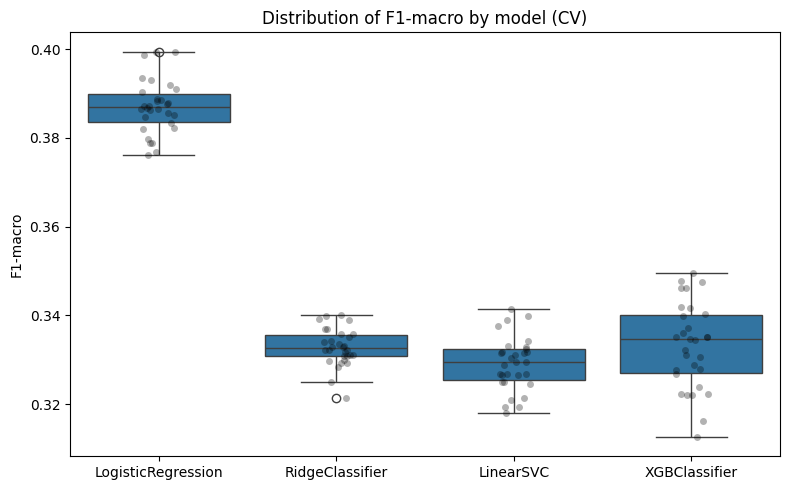

time: 233 ms (started: 2026-02-24 09:17:22 -03:00)


In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_long,
    x="Model",
    y="F1_macro"
)
sns.stripplot(
    data=df_long,
    x="Model",
    y="F1_macro",
    color="black",
    alpha=0.3
)

plt.title("Distribution of F1-macro by model (CV)")
plt.ylabel("F1-macro")
plt.xlabel("")
plt.tight_layout()
plt.show()